
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
a = 20.0      # Longitud en x (mm)
b = 10.0      # Longitud en y (mm)
D = 84.0      # Difusividad térmica (mm^2/s)

# Parámetros de la malla (FDM)
dx = 0.5      # Paso espacial en x
dy = 0.5      # Paso espacial en y
nx = int(a / dx) + 1
ny = int(b / dy) + 1

X, Y = np.meshgrid(np.linspace(0, a, nx), np.linspace(0, b, ny))

# Condición de frontera superior
def f(x):
    return 100 * np.sin(3 * np.pi * x / a)

In [3]:
T_estatica = np.zeros((ny, nx))
T_estatica[-1, :] = f(np.linspace(0, a, nx)) # Borde superior (y=b)

tolerancia = 1e-4
error = 1.0
while error > tolerancia:
    T_old = T_estatica.copy()

    T_estatica[1:-1, 1:-1] = 0.25 * (T_old[1:-1, 2:] + T_old[1:-1, :-2] +
                                   T_old[2:, 1:-1] + T_old[:-2, 1:-1])
    error = np.max(np.abs(T_estatica - T_old))

T_analitica = 100 * (np.sinh(3 * np.pi * Y / a) / np.sinh(3 * np.pi * b / a)) * np.sin(3 * np.pi * X / a)

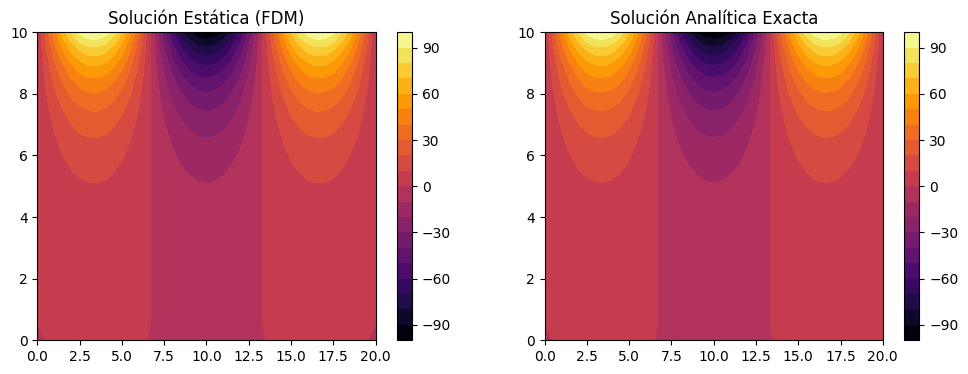

In [4]:
# Comparación gráfica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
c1 = ax1.contourf(X, Y, T_estatica, 20, cmap='inferno')
ax1.set_title("Solución Estática (FDM)")
fig.colorbar(c1, ax=ax1)

c2 = ax2.contourf(X, Y, T_analitica, 20, cmap='inferno')
ax2.set_title("Solución Analítica Exacta")
fig.colorbar(c2, ax=ax2)
plt.show()

BIEN....

Paso de tiempo utilizado: 0.000737 s


Text(0.5, 1.0, 'Difusión en el tiempo: t = 0.000 s')

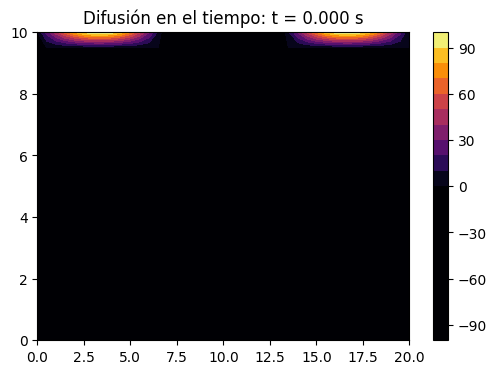

In [5]:
# Determinar paso de tiempo estable (Criterio CFL)
dt = 0.99 * (1.0 / (2 * D * (1/dx**2 + 1/dy**2)))
print(f"Paso de tiempo utilizado: {dt:.6f} s")

T_transient = np.zeros((ny, nx))
T_transient[-1, :] = f(np.linspace(0, a, nx)) # Las fronteras se mantienen

fig_anim, ax_anim = plt.subplots(figsize=(6, 4))
cax = ax_anim.contourf(X, Y, T_transient, 20, cmap='inferno', vmin=0, vmax=100)
fig_anim.colorbar(cax)
ax_anim.set_title("Difusión en el tiempo: t = 0.000 s")

In [6]:
def update(frame):
    global T_transient
    # Realizamos varios pasos de cálculo por cada frame de video para acelerar
    pasos_por_frame = 20
    for _ in range(pasos_por_frame):
        T_new = T_transient.copy()
        # FTCS (Forward Time Central Space)
        d2T_dx2 = (T_transient[1:-1, 2:] - 2*T_transient[1:-1, 1:-1] + T_transient[1:-1, :-2]) / dx**2
        d2T_dy2 = (T_transient[2:, 1:-1] - 2*T_transient[1:-1, 1:-1] + T_transient[:-2, 1:-1]) / dy**2

        T_new[1:-1, 1:-1] = T_transient[1:-1, 1:-1] + D * dt * (d2T_dx2 + d2T_dy2)
        T_transient = T_new

    ax_anim.clear()
    tiempo_actual = frame * pasos_por_frame * dt
    cax = ax_anim.contourf(X, Y, T_transient, 20, cmap='inferno', vmin=0, vmax=100)
    ax_anim.set_title(f"Difusión en el tiempo: t = {tiempo_actual:.3f} s")
    return cax,

In [8]:
# Crear y guardar la animación
ani = animation.FuncAnimation(fig_anim, update, frames=60, blit=False)
ani.save('heat_diffusion.gif', writer='pillow', fps=15)
print("¡GIF guardado como 'heat_diffusion.gif'!")

¡GIF guardado como 'heat_diffusion.gif'!


In [ ]:
La animación no se ve muy bien... Nota 4.7